# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Benedictus Ryu Gunawan | 5054251001 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
TARGET = "Churn"
df = pd.read_csv("data/svm_data.csv")

print("Jumlah baris dan kolom:", df.shape)
print("Tipe data:")
display(df.dtypes)
print("Jumlah missing value:")
display(df.isnull().sum())
print("Jumlah baris duplikat:", int(df.duplicated().sum()))

Jumlah baris dan kolom: (7043, 21)
Tipe data:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Jumlah missing value:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Jumlah baris duplikat: 0


Distribusi kelas target:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi kelas:


Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64

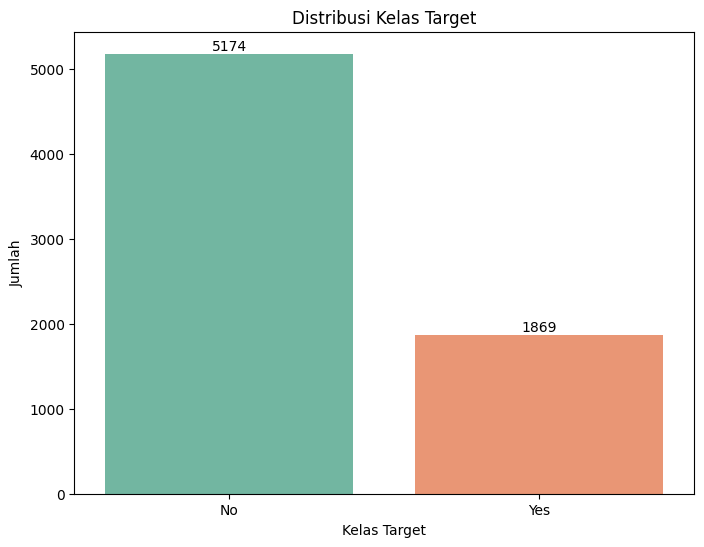

In [3]:
print("Distribusi kelas target:")
display(df[TARGET].value_counts())
print("Proporsi kelas:")
display(df[TARGET].value_counts(normalize=True).round(4))

plt.figure(figsize=(8, 6))
sns.countplot(x=TARGET, hue=TARGET, data=df, palette="Set2", legend=False)
plt.title("Distribusi Kelas Target")
for index, value in enumerate(df[TARGET].value_counts()):
    plt.text(index, value, str(value), ha="center", va="bottom")
plt.xlabel("Kelas Target")
plt.ylabel("Jumlah")
plt.show()

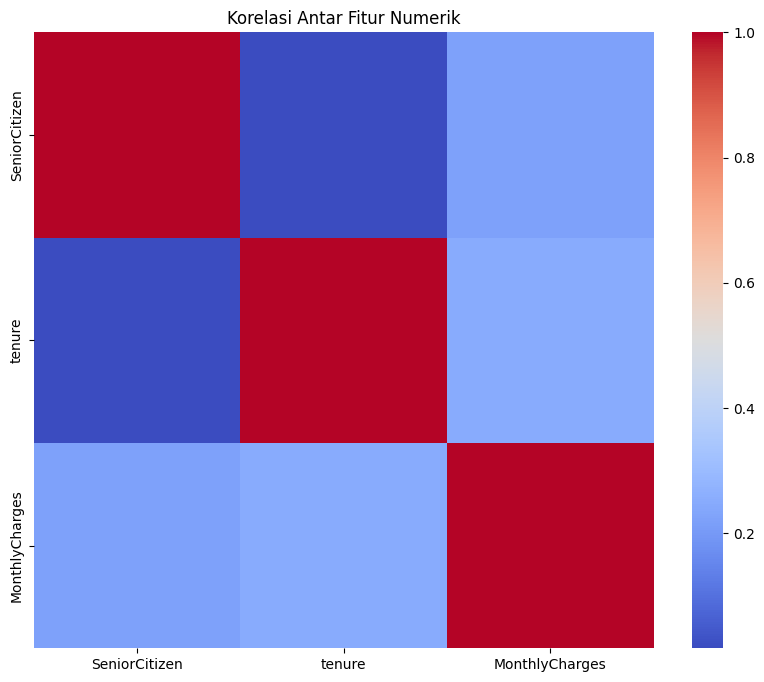

In [4]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Eksplorasi tambahan: pola churn berdasarkan tenure, kontrak, dan layanan internet


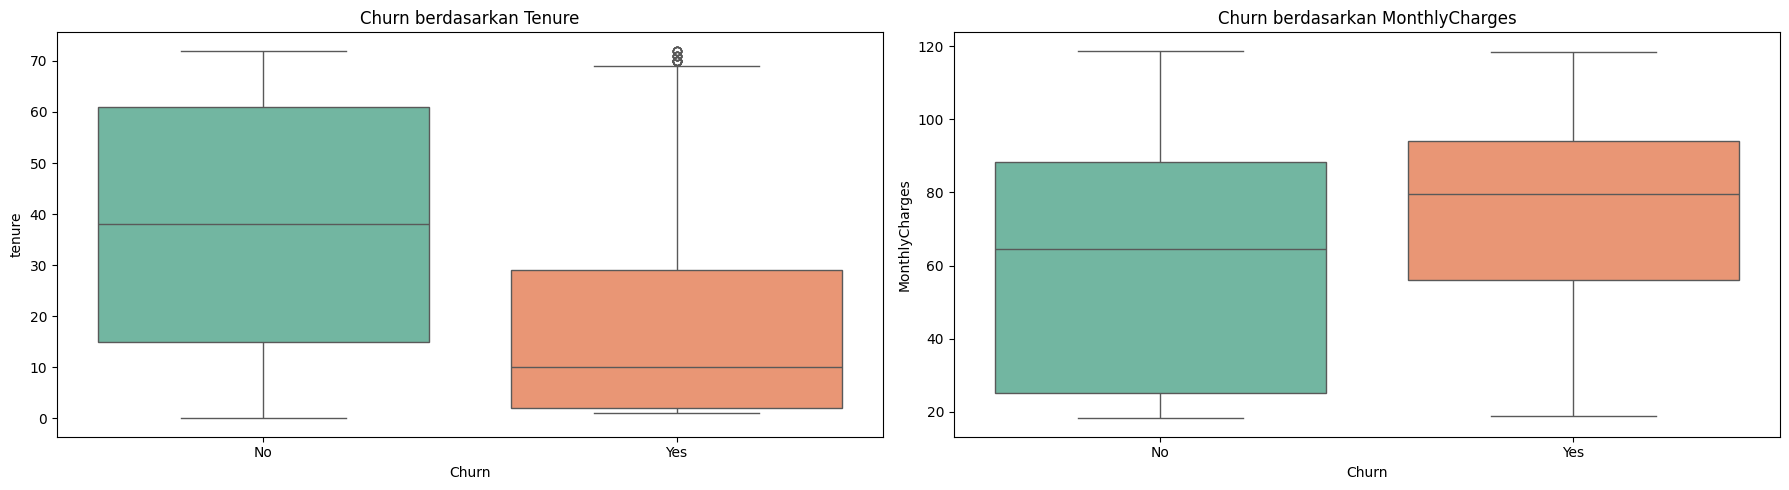

Tingkat churn per jenis kontrak:


Contract
Month-to-month    0.4271
One year          0.1127
Two year          0.0283
Name: churn_flag, dtype: float64

Tingkat churn per jenis layanan internet:


InternetService
DSL            0.1896
Fiber optic    0.4189
No             0.0740
Name: churn_flag, dtype: float64

In [5]:
print("Eksplorasi tambahan: pola churn berdasarkan tenure, kontrak, dan layanan internet")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.boxplot(x=TARGET, hue=TARGET, y="tenure", data=df, ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Churn berdasarkan Tenure")
sns.boxplot(x=TARGET, hue=TARGET, y="MonthlyCharges", data=df, ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Churn berdasarkan MonthlyCharges")
plt.tight_layout()
plt.show()

churn_rate = df.assign(churn_flag=(df[TARGET] == "Yes").astype(int)).groupby("Contract")["churn_flag"].mean().round(4)
print("Tingkat churn per jenis kontrak:")
display(churn_rate)

internet_rate = df.assign(churn_flag=(df[TARGET] == "Yes").astype(int)).groupby("InternetService")["churn_flag"].mean().round(4)
print("Tingkat churn per jenis layanan internet:")
display(internet_rate)

# 2. Preprocessing

In [6]:
blank_total = int((df["TotalCharges"].astype(str).str.strip() == "").sum())
print("Jumlah nilai kosong pada kolom TotalCharges:", blank_total)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Jumlah missing value setelah konversi:")
display(df.isnull().sum()[lambda s: s > 0])

rows_before = len(df)
df = df.dropna()
print("Jumlah baris sebelum dan sesudah pembuangan missing:", rows_before, "ke", len(df))
print("Jumlah missing value akhir:", int(df.isnull().sum().sum()))

Jumlah nilai kosong pada kolom TotalCharges: 11
Jumlah missing value setelah konversi:


TotalCharges    11
dtype: int64

Jumlah baris sebelum dan sesudah pembuangan missing: 7043 ke 7032
Jumlah missing value akhir: 0


In [7]:
drop_cols = ["customerID"]
df = df.drop(columns=drop_cols)

cat_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c]) and c != TARGET]
print("Fitur kategorikal yang di-encode:", cat_cols)

X = pd.get_dummies(df.drop(columns=[TARGET]), columns=cat_cols, drop_first=True).astype(float)
y = (df[TARGET] == "Yes").astype(int)
print("Jumlah fitur setelah one-hot encoding:", X.shape)
print("Distribusi target:")
display(y.value_counts())

Fitur kategorikal yang di-encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Jumlah fitur setelah one-hot encoding: (7032, 30)
Distribusi target:


Churn
0    5163
1    1869
Name: count, dtype: int64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Jumlah data train:", len(X_train))
print("Jumlah data test:", len(X_test))
print("Proporsi kelas train:", y_train.value_counts(normalize=True).round(4).to_dict())
print("Proporsi kelas test:", y_test.value_counts(normalize=True).round(4).to_dict())

Jumlah data train: 5625
Jumlah data test: 1407
Proporsi kelas train: {0: 0.7342, 1: 0.2658}
Proporsi kelas test: {0: 0.7342, 1: 0.2658}


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Jumlah fitur:", X_train_scaled.shape[1])
print("Rata-rata X_train_scaled:", np.round(X_train_scaled.mean(axis=0), 6))
print("Rata-rata X_test_scaled:", np.round(X_test_scaled.mean(axis=0), 6))
print("Rentang nilai X_train_scaled:", round(float(X_train_scaled.min()), 3), "sampai", round(float(X_train_scaled.max()), 3))

Jumlah fitur: 30
Rata-rata X_train_scaled: [-0. -0.  0.  0. -0. -0. -0.  0.  0.  0.  0. -0. -0.  0. -0. -0. -0. -0.
 -0.  0. -0.  0. -0. -0.  0. -0. -0. -0. -0.  0.]
Rata-rata X_test_scaled: [ 0.008451 -0.028619 -0.033386 -0.040721  0.02825  -0.035358 -0.011598
  0.003178 -0.003178 -0.020951 -0.011567  0.017029  0.017029 -0.004266
  0.017029 -0.058118  0.017029 -0.018321  0.017029 -0.051007  0.017029
 -0.047077  0.017029 -0.019003 -0.00987  -0.021061 -0.027074  0.003606
 -0.028533  0.032029]
Rentang nilai X_train_scaled: -3.053 sampai 3.053


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [10]:
C_BASE = 1.0
GAMMA_BASE = "scale"

model_linear = SVC(kernel="linear", C=C_BASE)
model_linear.fit(X_train_scaled, y_train)
print("Model linear selesai dilatih pada", X_train_scaled.shape)
print("Jumlah support vectors:", model_linear.n_support_.sum())

Model linear selesai dilatih pada (5625, 30)
Jumlah support vectors: 2571


In [11]:
y_pred_linear = model_linear.predict(X_test_scaled)
print("Jumlah support vectors per kelas:", model_linear.n_support_)

Jumlah support vectors per kelas: [1289 1282]


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [12]:
model_rbf = SVC(kernel="rbf", C=C_BASE, gamma=GAMMA_BASE)
model_rbf.fit(X_train_scaled, y_train)
print("Model RBF selesai dilatih pada", X_train_scaled.shape)
print("Jumlah support vectors:", model_rbf.n_support_.sum())

Model RBF selesai dilatih pada (5625, 30)
Jumlah support vectors: 2656


In [13]:
y_pred_rbf = model_rbf.predict(X_test_scaled)
print("Jumlah support vectors per kelas:", model_rbf.n_support_)

Jumlah support vectors per kelas: [1436 1220]


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [14]:
c_values = [0.01, 0.1, 1, 10, 100]
models_c = {}
results_c = {}

for c in c_values:
    clf = SVC(kernel="rbf", C=c, gamma=GAMMA_BASE)
    clf.fit(X_train_scaled, y_train)
    models_c[c] = clf
    results_c[c] = {
        "train_accuracy": clf.score(X_train_scaled, y_train),
        "test_accuracy": clf.score(X_test_scaled, y_test),
        "train_f1": f1_score(y_train, clf.predict(X_train_scaled), zero_division=0),
        "test_f1": f1_score(y_test, clf.predict(X_test_scaled), zero_division=0),
        "support_vectors": int(clf.n_support_.sum()),
    }
results_c

{0.01: {'train_accuracy': 0.7342222222222222,
  'test_accuracy': 0.7341862117981521,
  'train_f1': 0.0,
  'test_f1': 0.0,
  'support_vectors': 3018},
 0.1: {'train_accuracy': 0.8010666666666667,
  'test_accuracy': 0.7903340440653873,
  'train_f1': 0.5412054120541205,
  'test_f1': 0.5249597423510467,
  'support_vectors': 2756},
 1: {'train_accuracy': 0.8215111111111111,
  'test_accuracy': 0.7867803837953091,
  'train_f1': 0.6191198786039454,
  'test_f1': 0.5508982035928144,
  'support_vectors': 2656},
 10: {'train_accuracy': 0.8615111111111111,
  'test_accuracy': 0.7803837953091685,
  'train_f1': 0.72580077437522,
  'test_f1': 0.5726141078838174,
  'support_vectors': 2694},
 100: {'train_accuracy': 0.9255111111111111,
  'test_accuracy': 0.7547974413646056,
  'train_f1': 0.8607510800930541,
  'test_f1': 0.5466491458607096,
  'support_vectors': 2593}}

In [15]:
c_table = pd.DataFrame(results_c).T
c_table.index.name = "C"
c_table["gap"] = c_table["train_accuracy"] - c_table["test_accuracy"]
display(c_table)

,train_accuracy,test_accuracy,train_f1,test_f1,support_vectors,gap
C,,,,,,
0.01,0.734222,0.734186,0.000000,0.000000,3018.0,0.000036
0.10,0.801067,0.790334,0.541205,0.524960,2756.0,0.010733
1.00,0.821511,0.786780,0.619120,0.550898,2656.0,0.034731
10.00,0.861511,0.780384,0.725801,0.572614,2694.0,0.081127
100.00,0.925511,0.754797,0.860751,0.546649,2593.0,0.170714


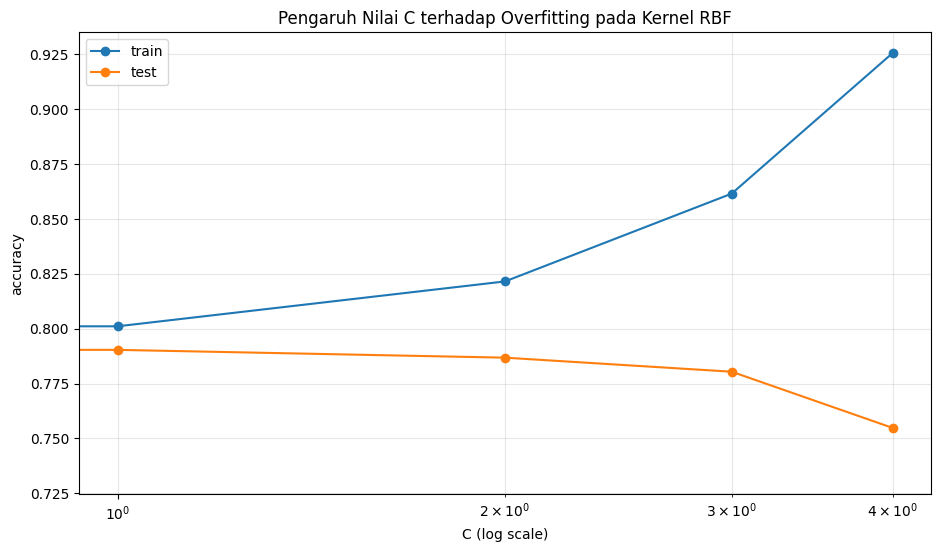

Nilai C dengan akurasi test tertinggi: 0.1


In [16]:
x_labels = [str(c) for c in c_values]
plt.figure(figsize=(11, 6))
plt.semilogx(x_labels, c_table["train_accuracy"], marker="o", label="train")
plt.semilogx(x_labels, c_table["test_accuracy"], marker="o", label="test")
plt.xlabel("C (log scale)")
plt.ylabel("accuracy")
plt.title("Pengaruh Nilai C terhadap Overfitting pada Kernel RBF")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

best_c = c_table["test_accuracy"].idxmax()
print("Nilai C dengan akurasi test tertinggi:", best_c)

# 4. Evaluasi Model

,model,accuracy,precision,recall,f1
0,linear C=1,0.798863,0.640867,0.553476,0.593974
1,RBF C=1 gamma=scale,0.786780,0.625850,0.491979,0.550898


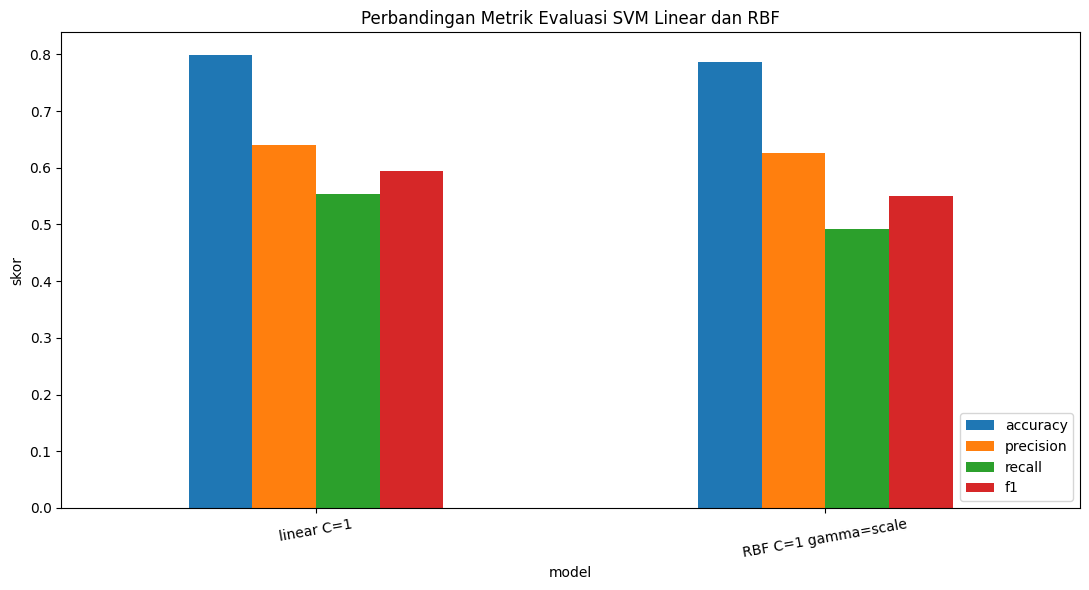

In [17]:
def metrics_block(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

evaluation = pd.DataFrame([
    {"model": "linear C=1", **metrics_block(y_test, y_pred_linear)},
    {"model": "RBF C=1 gamma=scale", **metrics_block(y_test, y_pred_rbf)},
])
display(evaluation)

ax = evaluation.set_index("model")[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(11, 6))
plt.title("Perbandingan Metrik Evaluasi SVM Linear dan RBF")
plt.xlabel("model")
plt.ylabel("skor")
plt.xticks(rotation=10)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

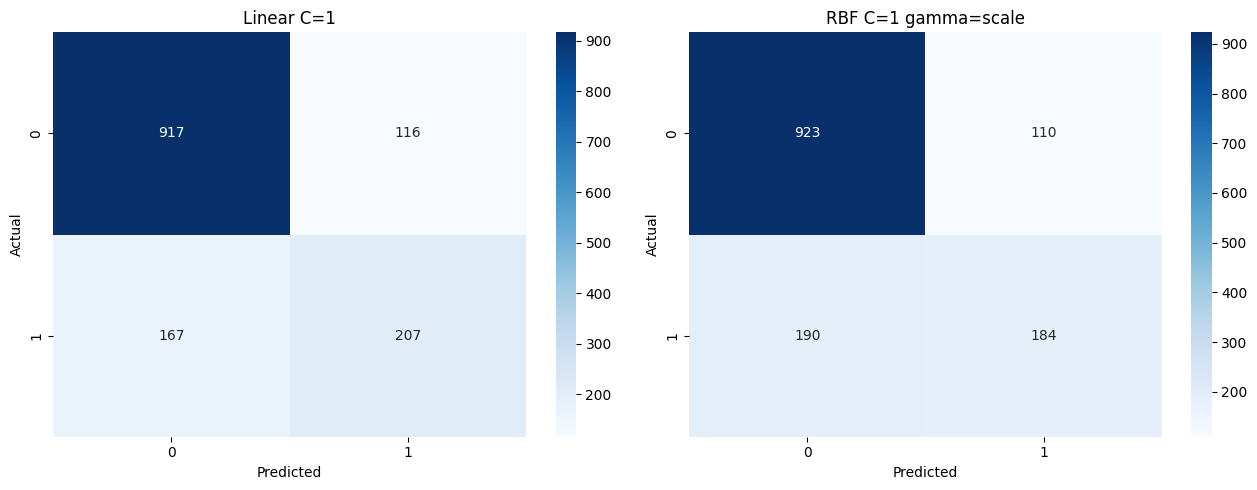

Confusion matrix linear (TN, FP, FN, TP): [917 116 167 207]
Confusion matrix RBF (TN, FP, FN, TP): [923 110 190 184]


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Linear C=1")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt="d", ax=ax[1], cmap="Blues")
ax[1].set_title("RBF C=1 gamma=scale")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

cm_linear = confusion_matrix(y_test, y_pred_linear).ravel()
cm_rbf = confusion_matrix(y_test, y_pred_rbf).ravel()
print("Confusion matrix linear (TN, FP, FN, TP):", cm_linear)
print("Confusion matrix RBF (TN, FP, FN, TP):", cm_rbf)

,model,support_vectors,persentase_data_train
0,linear C=1,2571,45.71
1,RBF C=1 gamma=scale,2656,47.22


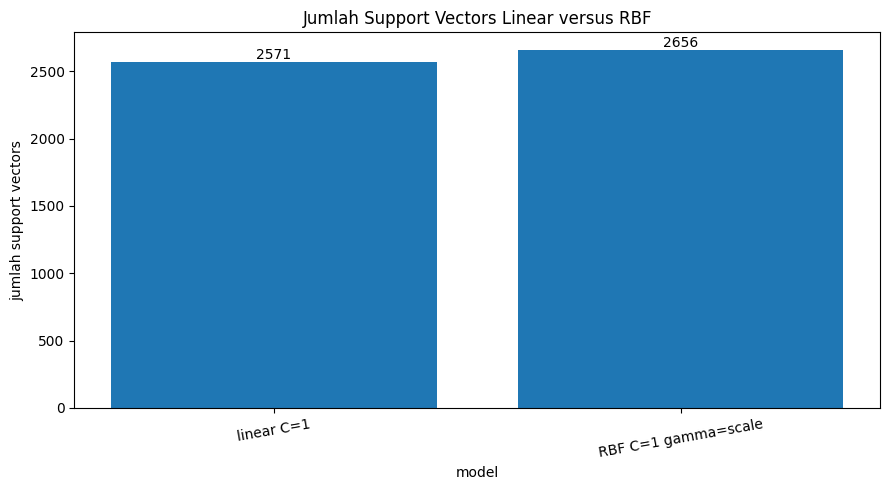

In [19]:
support_table = pd.DataFrame({
    "model": ["linear C=1", "RBF C=1 gamma=scale"],
    "support_vectors": [int(model_linear.n_support_.sum()), int(model_rbf.n_support_.sum())],
    "persentase_data_train": [
        round(model_linear.n_support_.sum() / len(X_train) * 100, 2),
        round(model_rbf.n_support_.sum() / len(X_train) * 100, 2),
    ],
})
display(support_table)

plt.figure(figsize=(9, 5))
plt.bar(support_table["model"], support_table["support_vectors"])
plt.title("Jumlah Support Vectors Linear versus RBF")
plt.xlabel("model")
plt.ylabel("jumlah support vectors")
for i, v in enumerate(support_table["support_vectors"]):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

Visualisasi decision boundary pada dua komponen PCA


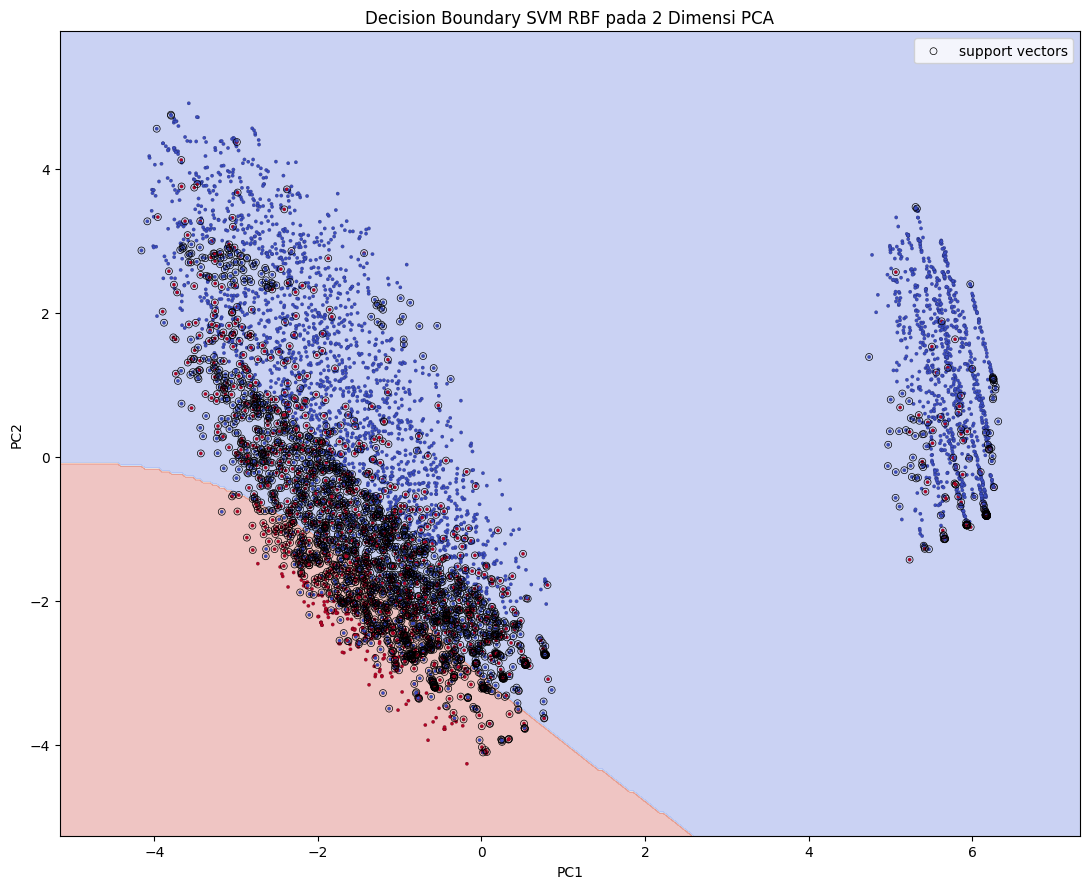

Explained variance ratio PC1 dan PC2: [0.3315 0.1196]
Akurasi model RBF pada 2D PCA: 0.7711
Jumlah support vectors pada 2D PCA: 2648


In [20]:
print("Visualisasi decision boundary pada dua komponen PCA")

pca_boundary = PCA(n_components=2, random_state=42)
X_train_pca = pca_boundary.fit_transform(X_train_scaled)
X_test_pca = pca_boundary.transform(X_test_scaled)

model_boundary = SVC(kernel="rbf", C=C_BASE, gamma=GAMMA_BASE)
model_boundary.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = model_boundary.predict(grid).reshape(xx.shape)

plt.figure(figsize=(11, 9))
plt.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap="coolwarm", s=6, edgecolors="k", linewidths=0.1
)
plt.scatter(
    model_boundary.support_vectors_[:, 0], model_boundary.support_vectors_[:, 1],
    facecolors="none", edgecolors="k", s=25, linewidths=0.5, label="support vectors"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary SVM RBF pada 2 Dimensi PCA")
plt.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratio PC1 dan PC2:", np.round(pca_boundary.explained_variance_ratio_, 4))
print("Akurasi model RBF pada 2D PCA:", round(model_boundary.score(X_test_pca, y_test), 4))
print("Jumlah support vectors pada 2D PCA:", model_boundary.n_support_.sum())

In [21]:
print("Eksperimen tambahan 1: pengaruh nilai gamma pada kernel RBF dengan C=1")

gamma_values = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
results_gamma = {}
gamma_predictions = {}
for gamma in gamma_values:
    clf = SVC(kernel="rbf", C=1.0, gamma=gamma)
    clf.fit(X_train_scaled, y_train)
    gamma_predictions[gamma] = clf.predict(X_test_scaled)
    results_gamma[gamma] = {
        "train_accuracy": clf.score(X_train_scaled, y_train),
        "test_accuracy": clf.score(X_test_scaled, y_test),
        "test_f1": f1_score(y_test, gamma_predictions[gamma], zero_division=0),
        "support_vectors": int(clf.n_support_.sum()),
    }
results_gamma

Eksperimen tambahan 1: pengaruh nilai gamma pada kernel RBF dengan C=1


{0.0001: {'train_accuracy': 0.7342222222222222,
  'test_accuracy': 0.7341862117981521,
  'test_f1': 0.0,
  'support_vectors': 2997},
 0.001: {'train_accuracy': 0.8023111111111111,
  'test_accuracy': 0.7981520966595593,
  'test_f1': 0.5798816568047337,
  'support_vectors': 2821},
 0.01: {'train_accuracy': 0.8097777777777778,
  'test_accuracy': 0.7917555081734187,
  'test_f1': 0.5540334855403348,
  'support_vectors': 2591},
 0.1: {'train_accuracy': 0.8508444444444444,
  'test_accuracy': 0.7896233120113717,
  'test_f1': 0.5634218289085545,
  'support_vectors': 3075},
 1.0: {'train_accuracy': 0.9427555555555556,
  'test_accuracy': 0.7540867093105899,
  'test_f1': 0.34962406015037595,
  'support_vectors': 4989}}

,train_accuracy,test_accuracy,test_f1,support_vectors,gap
gamma,,,,,
0.0010,0.802311,0.798152,0.579882,2821.0,0.004159
0.1000,0.850844,0.789623,0.563422,3075.0,0.061221
0.0100,0.809778,0.791756,0.554033,2591.0,0.018022
1.0000,0.942756,0.754087,0.349624,4989.0,0.188669
0.0001,0.734222,0.734186,0.000000,2997.0,0.000036


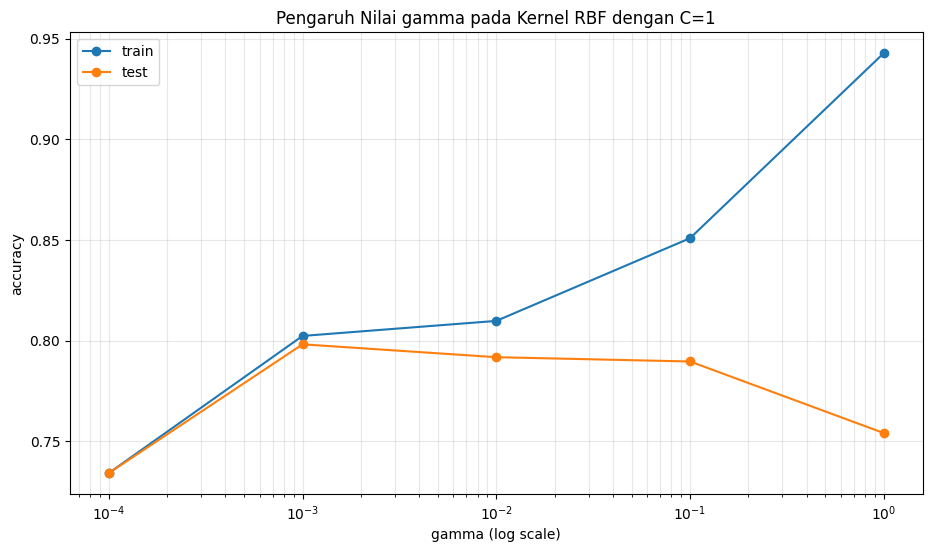

In [22]:
gamma_table = pd.DataFrame(results_gamma).T
gamma_table.index.name = "gamma"
gamma_table["gap"] = gamma_table["train_accuracy"] - gamma_table["test_accuracy"]
display(gamma_table.sort_values("test_f1", ascending=False))

plt.figure(figsize=(11, 6))
plt.semilogx(gamma_values, gamma_table["train_accuracy"], marker="o", label="train")
plt.semilogx(gamma_values, gamma_table["test_accuracy"], marker="o", label="test")
plt.xlabel("gamma (log scale)")
plt.ylabel("accuracy")
plt.title("Pengaruh Nilai gamma pada Kernel RBF dengan C=1")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

Eksperimen tambahan 2: grid C dan gamma pada kernel RBF


,0.001,0.01,0.1,1.0
0.1,0.0000,0.5566,0.4786,0.0000
1,0.5799,0.5540,0.5634,0.3496
10,0.5815,0.5625,0.5394,0.3679
100,0.5646,0.5628,0.4993,0.3748


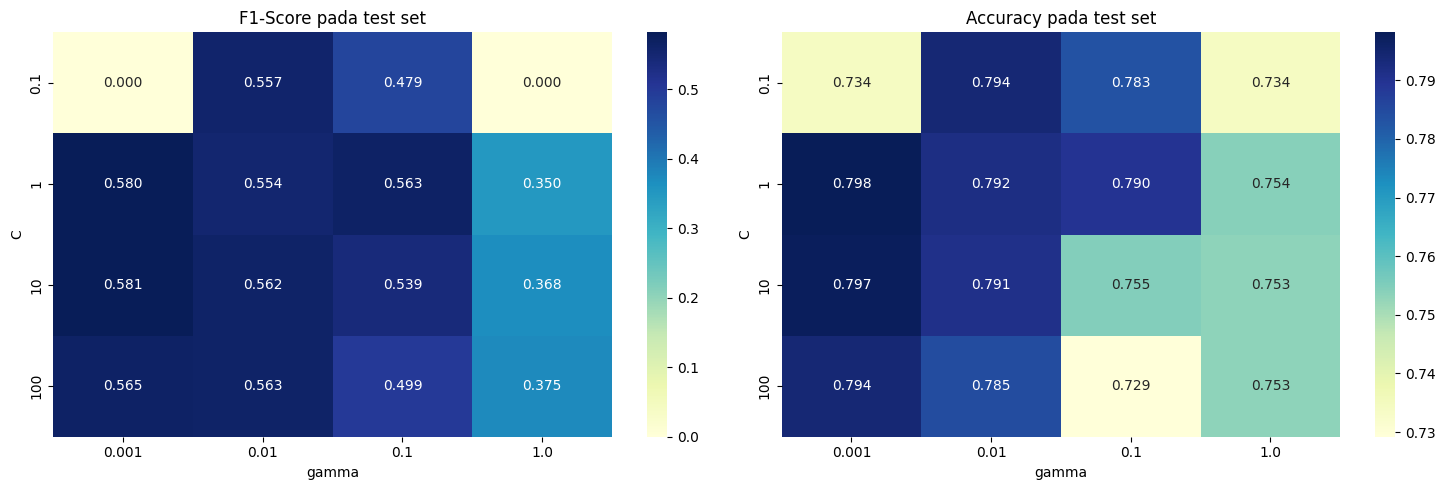

Kombinasi terbaik: C = 10 gamma = 0.001 dengan F1 0.5815


In [23]:
print("Eksperimen tambahan 2: grid C dan gamma pada kernel RBF")

c_grid = [0.1, 1, 10, 100]
gamma_grid = [1e-3, 1e-2, 1e-1, 1.0]
f1_grid = np.zeros((len(c_grid), len(gamma_grid)))
acc_grid = np.zeros((len(c_grid), len(gamma_grid)))

for i, c in enumerate(c_grid):
    for j, gamma in enumerate(gamma_grid):
        clf = SVC(kernel="rbf", C=c, gamma=gamma)
        clf.fit(X_train_scaled, y_train)
        f1_grid[i, j] = f1_score(y_test, clf.predict(X_test_scaled), zero_division=0)
        acc_grid[i, j] = accuracy_score(y_test, clf.predict(X_test_scaled))

f1_table = pd.DataFrame(f1_grid, index=[str(c) for c in c_grid], columns=[str(g) for g in gamma_grid])
display(f1_table.round(4))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(f1_table, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax[0])
ax[0].set_title("F1-Score pada test set")
ax[0].set_xlabel("gamma")
ax[0].set_ylabel("C")
sns.heatmap(pd.DataFrame(acc_grid, index=[str(c) for c in c_grid], columns=[str(g) for g in gamma_grid]).round(4),
            annot=True, fmt=".3f", cmap="YlGnBu", ax=ax[1])
ax[1].set_title("Accuracy pada test set")
ax[1].set_xlabel("gamma")
ax[1].set_ylabel("C")
plt.tight_layout()
plt.show()

best_f1 = float(np.max(f1_grid))
best_idx = np.unravel_index(np.argmax(f1_grid), f1_grid.shape)
print("Kombinasi terbaik: C =", c_grid[best_idx[0]], "gamma =", gamma_grid[best_idx[1]], "dengan F1", round(best_f1, 4))

In [24]:
print("Eksperimen tambahan 3: kernel polinomial dan perbandingan seluruh kernel")

kernels = {
    "linear C=1": SVC(kernel="linear", C=1.0),
    "rbf C=1 gamma=scale": SVC(kernel="rbf", C=1.0, gamma="scale"),
    "poly degree 2 C=1": SVC(kernel="poly", degree=2, C=1.0, gamma="scale"),
    "poly degree 3 C=1": SVC(kernel="poly", degree=3, C=1.0, gamma="scale"),
    "sigmoid C=1": SVC(kernel="sigmoid", C=1.0, gamma="scale"),
}
kernel_results = {}
kernel_predictions = {}
for name, clf in kernels.items():
    clf.fit(X_train_scaled, y_train)
    kernel_predictions[name] = clf.predict(X_test_scaled)
    kernel_results[name] = {
        **metrics_block(y_test, kernel_predictions[name]),
        "train_accuracy": clf.score(X_train_scaled, y_train),
        "support_vectors": int(clf.n_support_.sum()),
    }
kernel_results

Eksperimen tambahan 3: kernel polinomial dan perbandingan seluruh kernel


{'linear C=1': {'accuracy': 0.798862828713575,
  'precision': 0.6408668730650154,
  'recall': 0.553475935828877,
  'f1': 0.593974175035868,
  'train_accuracy': 0.8012444444444444,
  'support_vectors': 2571},
 'rbf C=1 gamma=scale': {'accuracy': 0.7867803837953091,
  'precision': 0.6258503401360545,
  'recall': 0.4919786096256685,
  'f1': 0.5508982035928144,
  'train_accuracy': 0.8215111111111111,
  'support_vectors': 2656},
 'poly degree 2 C=1': {'accuracy': 0.7924662402274343,
  'precision': 0.6413793103448275,
  'recall': 0.49732620320855614,
  'f1': 0.5602409638554217,
  'train_accuracy': 0.8112,
  'support_vectors': 2602},
 'poly degree 3 C=1': {'accuracy': 0.7917555081734187,
  'precision': 0.6494464944649446,
  'recall': 0.47058823529411764,
  'f1': 0.5457364341085271,
  'train_accuracy': 0.8224,
  'support_vectors': 2760},
 'sigmoid C=1': {'accuracy': 0.7341862117981521,
  'precision': 0.5,
  'recall': 0.5294117647058824,
  'f1': 0.5142857142857142,
  'train_accuracy': 0.7434666

,accuracy,precision,recall,f1,train_accuracy,support_vectors
linear C=1,0.798863,0.640867,0.553476,0.593974,0.801244,2571.0
poly degree 2 C=1,0.792466,0.641379,0.497326,0.560241,0.811200,2602.0
rbf C=1 gamma=scale,0.786780,0.625850,0.491979,0.550898,0.821511,2656.0
poly degree 3 C=1,0.791756,0.649446,0.470588,0.545736,0.822400,2760.0
sigmoid C=1,0.734186,0.500000,0.529412,0.514286,0.743467,1973.0


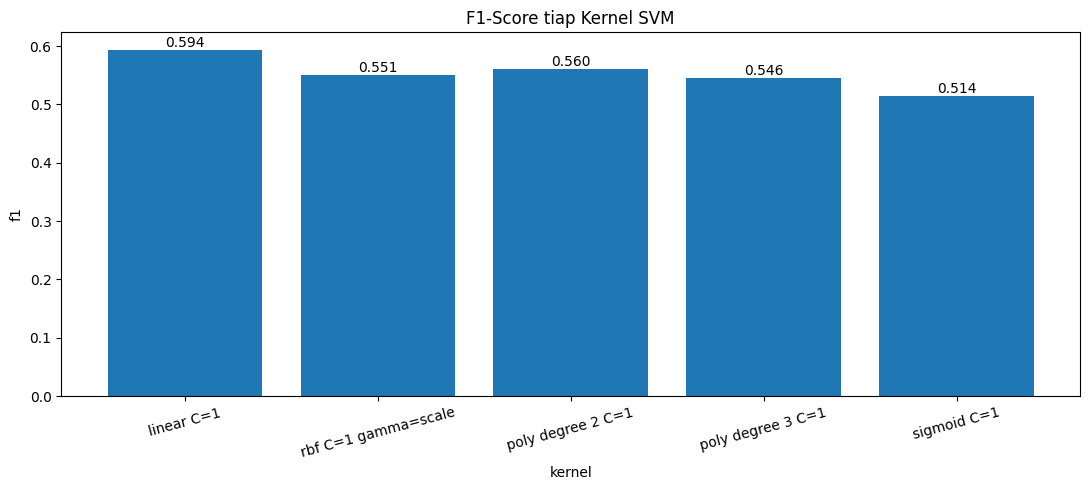

In [25]:
kernel_table = pd.DataFrame(kernel_results).T
display(kernel_table.sort_values("f1", ascending=False))

plt.figure(figsize=(11, 5))
plt.bar(kernel_table.index, kernel_table["f1"])
plt.title("F1-Score tiap Kernel SVM")
plt.xlabel("kernel")
plt.ylabel("f1")
for i, v in enumerate(kernel_table["f1"]):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [26]:
print("Eksperimen tambahan 4: class_weight untuk menangani ketidakseimbangan kelas")

weight_results = {}
balanced_predictions = {}
for name, kernel, gamma in [("linear", "linear", "scale"), ("rbf", "rbf", "scale")]:
    clf_none = SVC(kernel=kernel, C=1.0, gamma=gamma, class_weight=None)
    clf_none.fit(X_train_scaled, y_train)
    weight_results[f"{name} tanpa class_weight"] = {
        **metrics_block(y_test, clf_none.predict(X_test_scaled)),
        "support_vectors": int(clf_none.n_support_.sum()),
    }
    clf_bal = SVC(kernel=kernel, C=1.0, gamma=gamma, class_weight="balanced")
    clf_bal.fit(X_train_scaled, y_train)
    balanced_predictions[name] = clf_bal.predict(X_test_scaled)
    weight_results[f"{name} class_weight balanced"] = {
        **metrics_block(y_test, balanced_predictions[name]),
        "support_vectors": int(clf_bal.n_support_.sum()),
    }
weight_results

Eksperimen tambahan 4: class_weight untuk menangani ketidakseimbangan kelas


{'linear tanpa class_weight': {'accuracy': 0.798862828713575,
  'precision': 0.6408668730650154,
  'recall': 0.553475935828877,
  'f1': 0.593974175035868,
  'support_vectors': 2571},
 'linear class_weight balanced': {'accuracy': 0.6865671641791045,
  'precision': 0.4505169867060561,
  'recall': 0.8155080213903744,
  'f1': 0.5803996194100857,
  'support_vectors': 3270},
 'rbf tanpa class_weight': {'accuracy': 0.7867803837953091,
  'precision': 0.6258503401360545,
  'recall': 0.4919786096256685,
  'f1': 0.5508982035928144,
  'support_vectors': 2656},
 'rbf class_weight balanced': {'accuracy': 0.7270788912579957,
  'precision': 0.49155405405405406,
  'recall': 0.7780748663101604,
  'f1': 0.6024844720496895,
  'support_vectors': 3024}}

,accuracy,precision,recall,f1,support_vectors
linear tanpa class_weight,0.798863,0.640867,0.553476,0.593974,2571.0
linear class_weight balanced,0.686567,0.450517,0.815508,0.580400,3270.0
rbf tanpa class_weight,0.786780,0.625850,0.491979,0.550898,2656.0
rbf class_weight balanced,0.727079,0.491554,0.778075,0.602484,3024.0


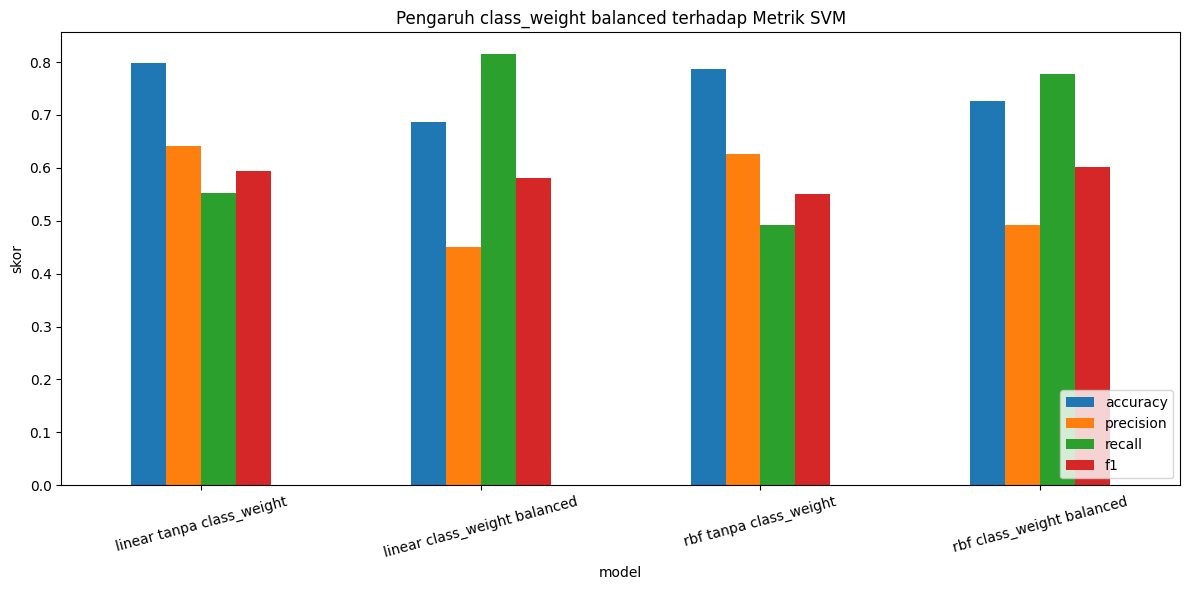

In [27]:
weight_table = pd.DataFrame(weight_results).T
display(weight_table)

ax = weight_table[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(12, 6))
plt.title("Pengaruh class_weight balanced terhadap Metrik SVM")
plt.xlabel("model")
plt.ylabel("skor")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [28]:
print("Eksperimen tambahan 5: reduksi fitur dengan SelectKBest dan PCA, serta SVM tanpa scaling")

kbest = SelectKBest(score_func=f_classif, k=15)
X_train_kbest = kbest.fit_transform(X_train_scaled, y_train)
X_test_kbest = kbest.transform(X_test_scaled)

model_kbest = SVC(kernel="rbf", C=1.0, gamma=GAMMA_BASE)
model_kbest.fit(X_train_kbest, y_train)

pca5 = PCA(n_components=5, random_state=42)
X_train_pca5 = pca5.fit_transform(X_train_scaled)
X_test_pca5 = pca5.transform(X_test_scaled)

model_pca5 = SVC(kernel="rbf", C=1.0, gamma=GAMMA_BASE)
model_pca5.fit(X_train_pca5, y_train)

model_no_scale = SVC(kernel="rbf", C=1.0, gamma="scale", max_iter=20000)
model_no_scale.fit(X_train, y_train)

feature_results = {
    "Baseline 30 fitur": {
        "n_features": X_train_scaled.shape[1],
        **metrics_block(y_test, y_pred_rbf),
    },
    "SelectKBest k=15": {
        "n_features": X_train_kbest.shape[1],
        **metrics_block(y_test, model_kbest.predict(X_test_kbest)),
    },
    "PCA 5 komponen": {
        "n_features": X_train_pca5.shape[1],
        **metrics_block(y_test, model_pca5.predict(X_test_pca5)),
    },
    "Tanpa scaling 30 fitur": {
        "n_features": X_train.shape[1],
        **metrics_block(y_test, model_no_scale.predict(X_test)),
    },
}
feature_results

Eksperimen tambahan 5: reduksi fitur dengan SelectKBest dan PCA, serta SVM tanpa scaling


{'Baseline 30 fitur': {'n_features': 30,
  'accuracy': 0.7867803837953091,
  'precision': 0.6258503401360545,
  'recall': 0.4919786096256685,
  'f1': 0.5508982035928144},
 'SelectKBest k=15': {'n_features': 15,
  'accuracy': 0.7910447761194029,
  'precision': 0.6438848920863309,
  'recall': 0.4786096256684492,
  'f1': 0.549079754601227},
 'PCA 5 komponen': {'n_features': 5,
  'accuracy': 0.7882018479033405,
  'precision': 0.6472868217054264,
  'recall': 0.446524064171123,
  'f1': 0.5284810126582279},
 'Tanpa scaling 30 fitur': {'n_features': 30,
  'accuracy': 0.7341862117981521,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0}}

,n_features,accuracy,precision,recall,f1,delta_f1_vs_baseline
Baseline 30 fitur,30.0,0.786780,0.625850,0.491979,0.550898,0.000000
SelectKBest k=15,15.0,0.791045,0.643885,0.478610,0.549080,-0.001818
PCA 5 komponen,5.0,0.788202,0.647287,0.446524,0.528481,-0.022417
Tanpa scaling 30 fitur,30.0,0.734186,0.000000,0.000000,0.000000,-0.550898


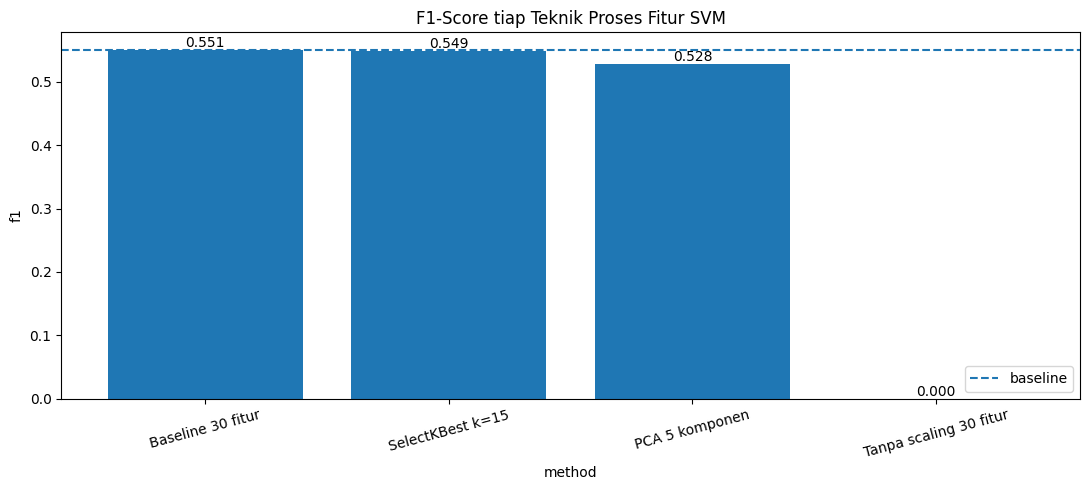

Total explained variance 5 komponen PCA: 0.6309
Rata-rata nilai absolut fitur tanpa scaling: 80.27
Rata-rata nilai absolut fitur setelah scaling: 0.87


In [29]:
feature_table = pd.DataFrame(feature_results).T
baseline_f1 = feature_table.loc["Baseline 30 fitur", "f1"]
feature_table["delta_f1_vs_baseline"] = feature_table["f1"] - baseline_f1
display(feature_table)

plt.figure(figsize=(11, 5))
plt.bar(feature_table.index, feature_table["f1"])
plt.axhline(baseline_f1, linestyle="--", label="baseline")
plt.title("F1-Score tiap Teknik Proses Fitur SVM")
plt.xlabel("method")
plt.ylabel("f1")
for i, v in enumerate(feature_table["f1"]):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

print("Total explained variance 5 komponen PCA:", round(float(pca5.explained_variance_ratio_.sum()), 4))
print("Rata-rata nilai absolut fitur tanpa scaling:", round(float(np.abs(X_train.to_numpy()).mean()), 3))
print("Rata-rata nilai absolut fitur setelah scaling:", round(float(np.abs(X_train_scaled).mean()), 3))

Rekap seluruh eksperimen SVM


,eksperimen,accuracy,precision,recall,f1,delta_f1_vs_linear
0,rbf class_weight balanced,0.727079,0.491554,0.778075,0.602484,0.008510
1,3.1 linear C=1,0.798863,0.640867,0.553476,0.593974,0.000000
2,linear class_weight balanced,0.686567,0.450517,0.815508,0.580400,-0.013575
3,gamma 1e-3,0.798152,0.649007,0.524064,0.579882,-0.014093
4,3.3 C=10,0.780384,0.593123,0.553476,0.572614,-0.021360
5,poly degree 2,0.792466,0.641379,0.497326,0.560241,-0.033733
6,3.2 RBF C=1 gamma=scale,0.786780,0.625850,0.491979,0.550898,-0.043076
7,SelectKBest k=15,0.791045,0.643885,0.478610,0.549080,-0.044894
8,3.3 C=100,0.754797,0.537468,0.556150,0.546649,-0.047325
9,PCA 5 komponen,0.788202,0.647287,0.446524,0.528481,-0.065493


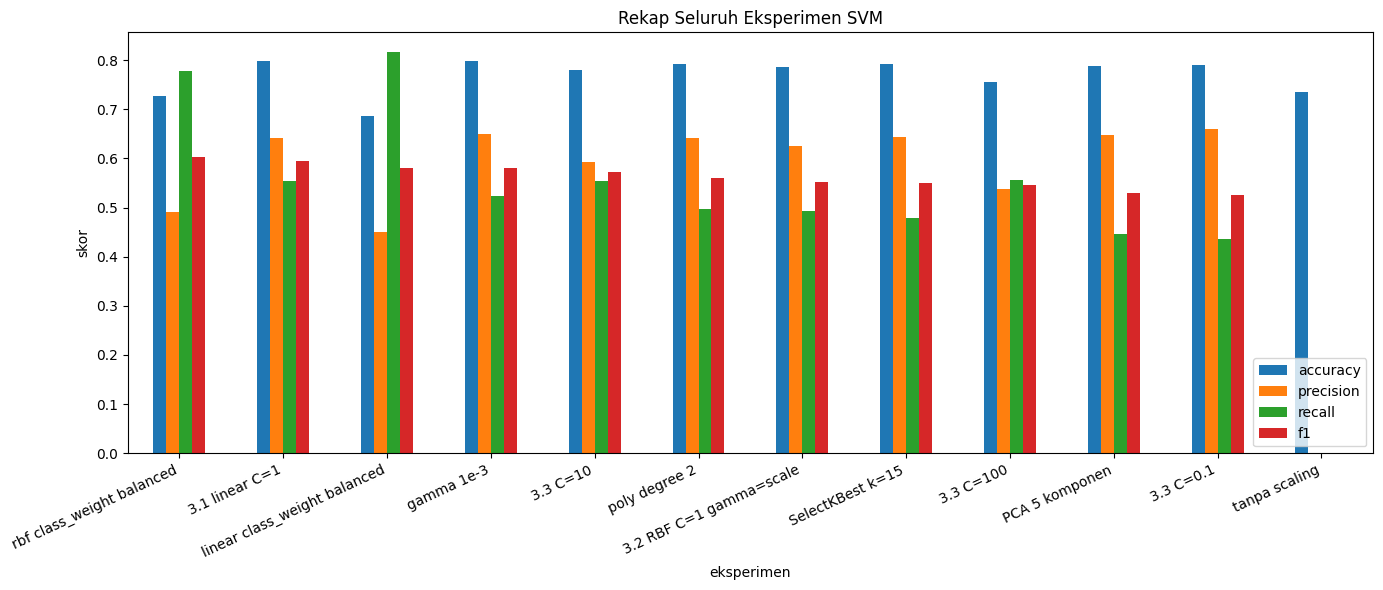

In [30]:
print("Rekap seluruh eksperimen SVM")

recap = pd.DataFrame([
    {"eksperimen": "3.1 linear C=1", **metrics_block(y_test, y_pred_linear)},
    {"eksperimen": "3.2 RBF C=1 gamma=scale", **metrics_block(y_test, y_pred_rbf)},
    {"eksperimen": "3.3 C=0.1", **metrics_block(y_test, models_c[0.1].predict(X_test_scaled))},
    {"eksperimen": "3.3 C=10", **metrics_block(y_test, models_c[10].predict(X_test_scaled))},
    {"eksperimen": "3.3 C=100", **metrics_block(y_test, models_c[100].predict(X_test_scaled))},
    {"eksperimen": "gamma 1e-3", **metrics_block(y_test, gamma_predictions[1e-3])},
    {"eksperimen": "poly degree 2", **metrics_block(y_test, kernel_predictions["poly degree 2 C=1"])},
    {"eksperimen": "linear class_weight balanced", **metrics_block(y_test, balanced_predictions["linear"])},
    {"eksperimen": "rbf class_weight balanced", **metrics_block(y_test, balanced_predictions["rbf"])},
    {"eksperimen": "SelectKBest k=15", **metrics_block(y_test, model_kbest.predict(X_test_kbest))},
    {"eksperimen": "PCA 5 komponen", **metrics_block(y_test, model_pca5.predict(X_test_pca5))},
    {"eksperimen": "tanpa scaling", **metrics_block(y_test, model_no_scale.predict(X_test))},
])
recap = recap.sort_values("f1", ascending=False).reset_index(drop=True)
recap["delta_f1_vs_linear"] = recap["f1"] - metrics_block(y_test, y_pred_linear)["f1"]
display(recap)

ax = recap.set_index("eksperimen")[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(14, 6))
plt.title("Rekap Seluruh Eksperimen SVM")
plt.xlabel("eksperimen")
plt.ylabel("skor")
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 5. Analisis

### 5.1 Perbandingan kernel Linear dan RBF

Dengan C sama-sama 1, kernel Linear mengalahkan RBF di semua metrik: accuracy 0.799 berbanding 0.787, precision 0.641 berbanding 0.626, recall 0.553 berbanding 0.492, dan F1 0.594 berbanding 0.551. Selisih F1 sekitar 0.043.

Hasil ini konsisten dengan temuan EDA. Setelah one-hot encoding, 30 fitur dataset telco churn sebagian besar berupa variabel biner kategorikal seperti jenis kontrak, metode pembayaran, dan status layanan. Variabel biner seperti itu lebih mudah dipisahkan oleh kombinasi hyperplane, sehingga kernel linear sudah cukup. Visualisasi decision boundary pada dua komponen PCA menunjukkan batas churn yang cukup terstruktur, tanpa pola radial yang jelas.

Sebaliknya kernel RBF bekerja dengan jarak radial di sekitar support vector. Ketika data berupa kombinasi biner di banyak dimensi, jarak RBF kehilangan makna karena dua pelanggan dengan profil layanan berbeda bisa memiliki jarak RBF yang hampir sama. Akibatnya RBF hanya menambah fleksibilitas tanpa tambahan informasi, sehingga recall justru turun dari 0.553 ke 0.492.

Dari confusion matrix, Linear menghasilkan TN 917, FP 116, FN 167, TP 207, sedangkan RBF menghasilkan TN 923, FP 110, FN 184, TP 184. RBF sedikit lebih tinggi dalam menandai churn sebagai positif, tetapi kehilangan jauh lebih banyak pelanggan yang sebenarnya churn. Untuk kasus ini, lebih baik tidak melakukan false positive daripada melewatkan pelanggan yang akan churn.

### 5.2 Pengaruh nilai C terhadap overfitting

Eksperimen memakai kernel RBF dengan gamma scale sebesar 0.0333 dan variasi C 0.01, 0.1, 1, 10, dan 100.

Pada C 0.01, accuracy train dan test sama-sama 0.734 dengan F1 0.000 dan seluruh prediksi jatuh ke kelas No. Ini kondisi underfit karena margin yang terlalu lebar membuat semua titik dianggap berada di dalam margin. Pada C 0.1, accuracy test melonjak ke 0.790 dengan F1 0.525. Pada C 1, accuracy test 0.787 dengan F1 0.551. Pada C 10, accuracy test 0.780 dengan F1 0.573. Pada C 100, accuracy test anjlok ke 0.755 dengan F1 0.547.

Sementara itu train accuracy naik monoton dari 0.734 menjadi 0.926, sedangkan test accuracy memuncak di C 0.1 lalu menurun. Gap train minus test melebar dari 0.00004 pada C 0.01 menjadi 0.011 pada C 0.1, 0.035 pada C 1, 0.081 pada C 10, dan 0.171 pada C 100. Ini overfitting klasik pada SVM, dengan overfitting dimulai sekitar C 1 dan menjadi fatal pada C 100.

Jumlah support vectors bergerak dari 3018 pada C 0.01, 2756 pada C 0.1, 2656 pada C 1, 2694 pada C 10, dan 2593 pada C 100. Menurunnya jumlah support vectors seiring naiknya C terjadi karena C besar mengizinkan titik yang melanggar margin untuk tetap dihitung sebagai support vector, sehingga batas keputusan menjadi lebih kompleks dan lebih dekat ke data train.

### 5.3 Pengaruh nilai gamma pada kernel RBF

Dengan C dikunci pada 1, sweep gamma dari 1e-4 sampai 1.0 memberi hasil berikut. Gamma 1e-4 menghasilkan accuracy 0.734 dengan F1 0.000 karena kernel terlalu lebar sehingga semua titik dianggap mirip. Gamma 1e-3 menjadi titik terbaik dengan accuracy test 0.798 dan F1 0.580. Gamma 1e-2 sedikit turun ke 0.792 dengan F1 0.554. Gamma 1e-1 ke 0.790 dengan F1 0.563. Gamma 1.0 anjlok ke 0.754 dengan F1 0.350.

Gap train minus test juga melebar dari 0.004 pada gamma 1e-3, 0.018 pada gamma 1e-2, 0.061 pada gamma 1e-1, dan 0.189 pada gamma 1.0. Gamma yang terlalu besar membuat setiap support vector hanya berpengaruh pada area sangat kecil sehingga batas keputusan menjadi zig zag dan sangat overfit. Jumlah support vectors juga melonjak ke 4989 pada gamma 1.0 dari 2821 pada gamma 1e-3.

Nilai gamma scale 0.0333 dari sklearn ternyata tidak optimal karena sudah berada di kurva yang menurun. Grid search C dan gamma menunjukkan kombinasi terbaik ada di C 10 dan gamma 0.001 dengan F1 0.582, sedikit di atas gamma 0.001 dengan C 1 sebesar 0.580. Region C 0.1 dengan gamma 0.001 menghasilkan F1 0.000, menandakan model belum terlatih cukup.

### 5.4 Jumlah support vectors dan kompleksitas batas

Linear C 1 memakai 2571 support vectors atau 45.71 persen dari 5625 data train, dengan pembagian 1289 pada kelas No dan 1282 pada kelas Yes. RBF C 1 dengan gamma scale memakai 2656 support vectors atau 47.22 persen, dengan 1436 pada kelas No dan 1220 pada kelas Yes.

Keduanya menangkap lebih dari separuh data, yang menunjukkan kedua batas keputusan cukup kompleks dan tidak dapat dibentuk oleh sebagian kecil data saja. RBF memiliki 85 support vectors lebih banyak, sesuai dengan fakta bahwa kernel RBF membentuk batas non-linear sehingga lebih banyak titik berada tepat di batas margin.

Pada visualisasi PCA dua dimensi, RBF menghasilkan 2648 support vectors dengan accuracy 0.771. Nilai ini lebih rendah dari accuracy 30 dimensi sebesar 0.787 karena dua komponen PCA hanya menyimpan 0.331 dan 0.120 dari variance, total 0.451, sehingga informasi krusial seperti jenis kontrak dan tenure hilang.

Pada pembagian per kelas, RBF memiliki 1436 support vectors pada kelas No dan 1220 pada kelas Yes, artinya sebagian besar batas keputusan RBF ditentukan oleh pola pelanggan yang tidak churn. Ini konsisten dengan recall yang lebih rendah dan F1 yang lebih buruk dibanding Linear yang pembagikannya hampir seimbang.

### 5.5 Perbandingan kernel polinomial dan sigmoid

Kernel Linear tetap terbaik dengan F1 0.594. Poly degree 2 menghasilkan F1 0.560 dengan accuracy 0.792, poly degree 3 F1 0.546 dengan accuracy 0.792, RBF F1 0.551, dan sigmoid F1 0.514 dengan accuracy 0.734.

Poly degree 2 sedikit lebih baik dari RBF, menunjukkan bahwa polinomial degree dua cukup untuk menangkap interaksi kuadratik antar fitur tanpa kompleksitas radial penuh. Sigmoid jelas lebih buruk karena bentuknya yang monoton membuat kernel tidak mampu memisahkan kelas secara nonlinear dengan baik pada data ini.

### 5.6 class_weight untuk ketidakseimbangan kelas

Dataset telco churn cukup imbalance dengan 73.46 persen kelas No berbanding 26.54 persen kelas Yes. Dengan class_weight balanced, kernel Linear mengubah accuracy dari 0.799 menjadi 0.687, precision turun dari 0.641 menjadi 0.451, recall naik dari 0.553 menjadi 0.816, dan F1 turun sedikit dari 0.594 menjadi 0.580.

Pada kernel RBF, class_weight balanced mengubah accuracy dari 0.787 menjadi 0.727, precision turun dari 0.626 menjadi 0.492, recall naik dari 0.492 menjadi 0.778, dan F1 naik dari 0.551 menjadi 0.602. Varian RBF balanced ini menjadi model dengan F1 tertinggi di seluruh notebook.

Jumlah support vectors juga naik, dari 2571 ke 3270 pada Linear dan dari 2656 ke 3024 pada RBF. Kenaikan ini karena bobot kelas membuat semua pelanggan churn dianggap layak menjadi support vector, sehingga batas keputusan digeser lebih dekat ke kelas minoritas.

Tradeoff ini penting untuk interpretasi bisnis. Untuk target kampanye retensi, false negative berarti pelanggan yang churn tidak mendapat penawaran, sedangkan false positive berarti menawarkan diskon ke pelanggan yang tetap. Bila biaya kehilangan pelanggan lebih besar daripada biaya diskon, recall 0.816 dari Linear balanced adalah pilihan yang wajar walaupun accuracy turun ke 0.687.

### 5.7 Pengaruh feature scaling dan reduksi fitur

Tanpa scaling, kernel RBF dengan gamma scale menghasilkan accuracy 0.734, precision 0.000, recall 0.000, dan F1 0.000. Seluruh prediksi menjadi kelas No. Penyebabnya adalah rentang fitur yang sangat lebar, TotalCharges mencapai 8684.8 sementara fitur lain bernilai 1 sampai 3, sehingga jarak RBF hampir sepenuhnya ditentukan oleh TotalCharges dan fitur lain kehilangan makna. Rata-rata nilai absolut fitur tanpa scaling adalah 80.27, sedangkan setelah scaling 0.87.

SelectKBest dengan k 15 hampir identik dengan baseline, accuracy 0.791 berbanding 0.787 dengan F1 0.549 berbanding 0.551 dan delta F1 -0.002. PCA 5 komponen sedikit lebih rendah dengan accuracy 0.788 dan F1 0.528 dengan delta F1 -0.022, dan hanya menyimpan 0.631 dari total variance.

Tidak ada gunanya reduksi fitur pada model ini karena one-hot encoding sudah menghasilkan matriks yang cukup jarang dan tidak bermasalah secara komputasi. Feature scaling jauh lebih menentukan daripada feature selection, dan kegagalan total tanpa scaling membuktikan bahwa skala fitur adalah faktor paling kritikal bagi SVM.

# 6. Kesimpulan dan Saran

### Kesimpulan

1. Kernel Linear unggul dari RBF dengan F1 0.594 berbanding 0.551 dan accuracy 0.799 berbanding 0.787 pada C 1. Penyebabnya 30 fitur hasil one-hot encoding berupa variabel biner yang lebih cocok dipisahkan hyperplane, sedangkan kernel RBF justru menurunkan recall dari 0.553 ke 0.492.
2. Overfitting pada C dimulai sekitar C 1 dengan gap train minus test 0.035 dan menjadi fatal pada C 100 dengan gap 0.171. Test accuracy memuncak di C 0.1 sebesar 0.790 sementara train accuracy naik monoton ke 0.926. Gamma scale 0.0333 juga tidak optimal karena sweep gamma menunjukkan titik terbaik di gamma 0.001 dengan F1 0.580.
3. Kernel Linear memakai 2571 support vectors atau 45.71 persen data train, sedangkan RBF memakai 2656 atau 47.22 persen. Kenaikan jumlah support vectors pada RBF mengikuti kompleksitas batas non-linear, dan pada RBF support vectors menumpuk di kelas No sehingga menjelaskan recall yang lebih rendah.
4. class_weight balanced adalah cara paling efektif menangani imbalance, terutama pada RBF dengan F1 0.602 dan recall 0.778, meski accuracy turun dari 0.787 ke 0.727. Feature scaling adalah faktor penentu terbesar, tanpa scaling RBF gagal total dengan F1 0.000 karena jarak didominasi TotalCharges.
5. Reduksi fitur tidak diperlukan. SelectKBest k 15 nyaris identik dengan baseline dengan delta F1 -0.002, PCA 5 komponen turun dengan delta F1 -0.022. Feature engineering pada Contract, tenure, dan InternetService lebih bermotif daripada mereduksi dimensi.

### Saran

1. Lakukan GridSearchCV pada C dan gamma dengan StratifiedKFold minimal 5 fold, dan gunakan F1 atau recall sebagai scoring karena accuracy menyesatkan pada data dengan 73 persen kelas No.
2. Perbaiki fitur kategorikal dengan mengubah SeniorCitizen menjadi biner dan mengelompokkan InternetService, lalu coba threshold tuning pada decision_function agar mendapat tradeoff recall dan precision yang sesuai biaya bisnis.
3. Bandingkan dengan model yang lebih stabil pada data tabular imbalance seperti Logistic Regression dengan regularisasi, Random Forest, Gradient Boosting, dan XGBoost sebagai pembanding yang adil dengan SVM.
4. Validasi robustness dengan cross-validation berulang dan periksa signifikansi perbedaan F1 antar kernel memakai bootstrap pada test set, karena selisih 0.043 masih mungkin mengandung noise.